## Step 1: Importing Libraies and Dataset

### Python libraries make it easy for us to handle the data and perform typical and complex tasks with a single line of code.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_error as mae
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('ola (1).csv')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,1/1/2011 0:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778
1,1/1/2011 1:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093
2,1/1/2011 2:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595
3,1/1/2011 3:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549
4,1/1/2011 4:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137


In [4]:
df.shape

(10886, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        9254 non-null   float64
 4   humidity    9254 non-null   float64
 5   windspeed   9254 non-null   float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 765.6+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.493937,1.120531,1.000000,1.000000,2.000000,3.000000,4.000000
weather,10886.0,2.491916,1.123139,1.000000,1.000000,2.000000,4.000000,4.000000
temp,9254.0,23.240116,20.311144,-22.743852,12.470555,20.743790,29.394576,211.102548
humidity,9254.0,124.452421,75.568291,32.713561,87.846187,112.180064,137.301002,672.687236
windspeed,9254.0,34.549616,28.417263,-1.407737,17.963252,30.945593,44.029018,244.921965
casual,10886.0,24.517545,14.390014,0.000000,12.000000,25.000000,37.000000,49.000000
registered,10886.0,99.551442,57.541131,0.000000,50.000000,100.000000,149.000000,199.000000
count,10886.0,224.177267,75.228602,-12.769738,170.140221,224.257587,278.407366,464.839068


# Step 2: Feature Engineering

In [7]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.hour

df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4


In [8]:
df["date"] = pd.to_datetime(df["date"])

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,1,1,2011
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,1,1,2011
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,1,1,2011
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,1,1,2011
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,1,1,2011


### Whether it is a weekend or a weekday must have some effect on the ride request count.

In [9]:
from datetime import datetime

df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

def weekend_or_weekday(year, month, day):
    try:
        d = datetime(year, month, day)
        return 0 if d.weekday() > 4 else 1
    except ValueError:
        return np.nan 

df['weekday'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)

df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year,weekday
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,1,1,2011,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,1,1,2011,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,1,1,2011,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,1,1,2011,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,1,1,2011,0


### Bike ride demands are also affected by whether it is am or pm.

In [10]:
def am_or_pm(x):
    if x > 11:
        return 1
    else:
        return 0


df['am_or_pm'] = df['time'].apply(am_or_pm)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year,weekday,am_or_pm
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,1,1,2011,0,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,1,1,2011,0,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,1,1,2011,0,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,1,1,2011,0,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,1,1,2011,0,0


### It would be nice to have a column which can indicate whether there was any holiday on a particular day or not.

In [11]:
from datetime import date
import holidays


def is_holiday(x):

    india_holidays = holidays.country_holidays('IN')

    if india_holidays.get(x):
        return 1
    else:
        return 0


df['holidays'] = df['date'].apply(is_holiday)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year,weekday,am_or_pm,holidays
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,1,1,2011,0,0,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,1,1,2011,0,0,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,1,1,2011,0,0,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,1,1,2011,0,0,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,1,1,2011,0,0,0


### Now let's remove the columns which are not useful for us.

In [12]:
df.drop(['datetime', 'date'],
        axis=1,
        inplace=True)

## Step 3: Exploratory Data Analysis

### We have added some features to our dataset using some assumptions. Now let's check what are the relations between different features with the target feature.

In [13]:
df.isnull().sum()

season           0
weather          0
temp          1632
humidity      1632
windspeed     1632
casual           0
registered       0
count            0
time             0
day              0
month            0
year             0
weekday          0
am_or_pm         0
holidays         0
dtype: int64

### Now, we will check for any relation between the ride request count with respect to the day, time, or month.

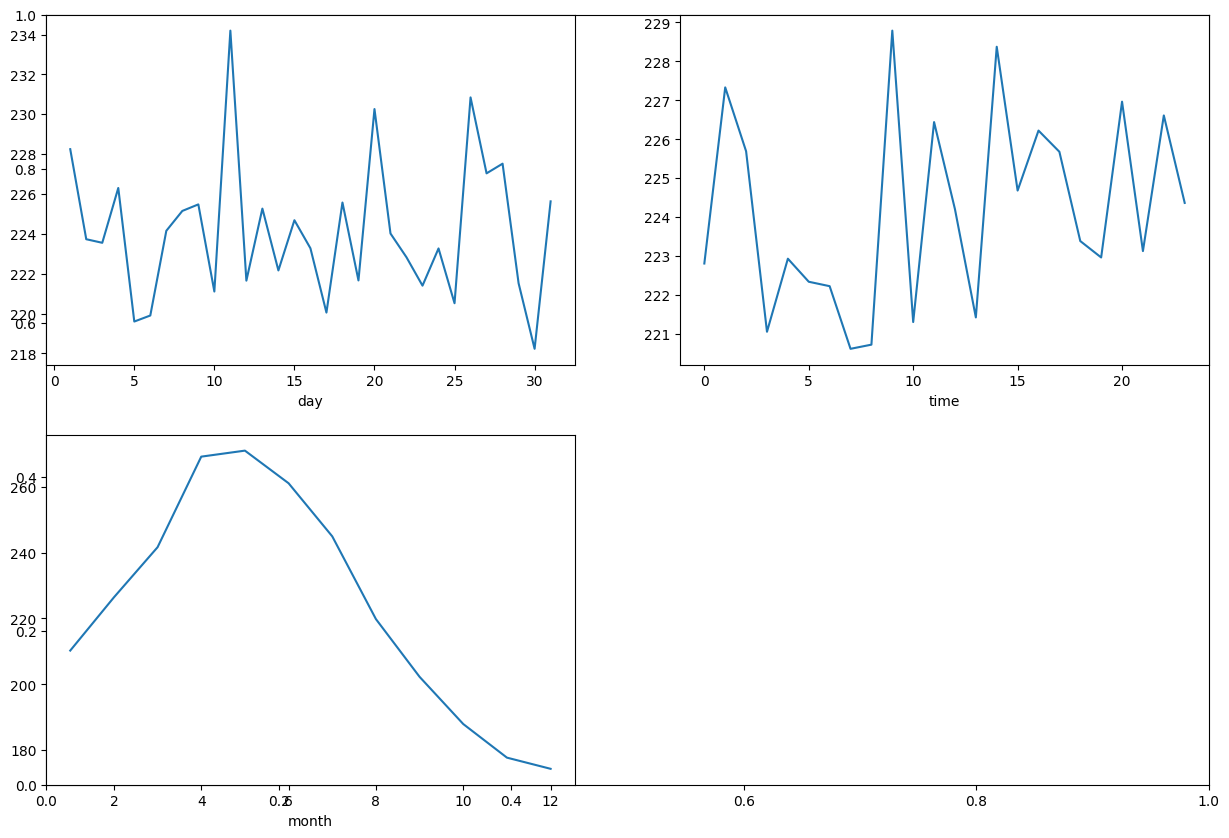

In [14]:
features = ['day', 'time', 'month']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col).mean()['count'].plot()
plt.show()

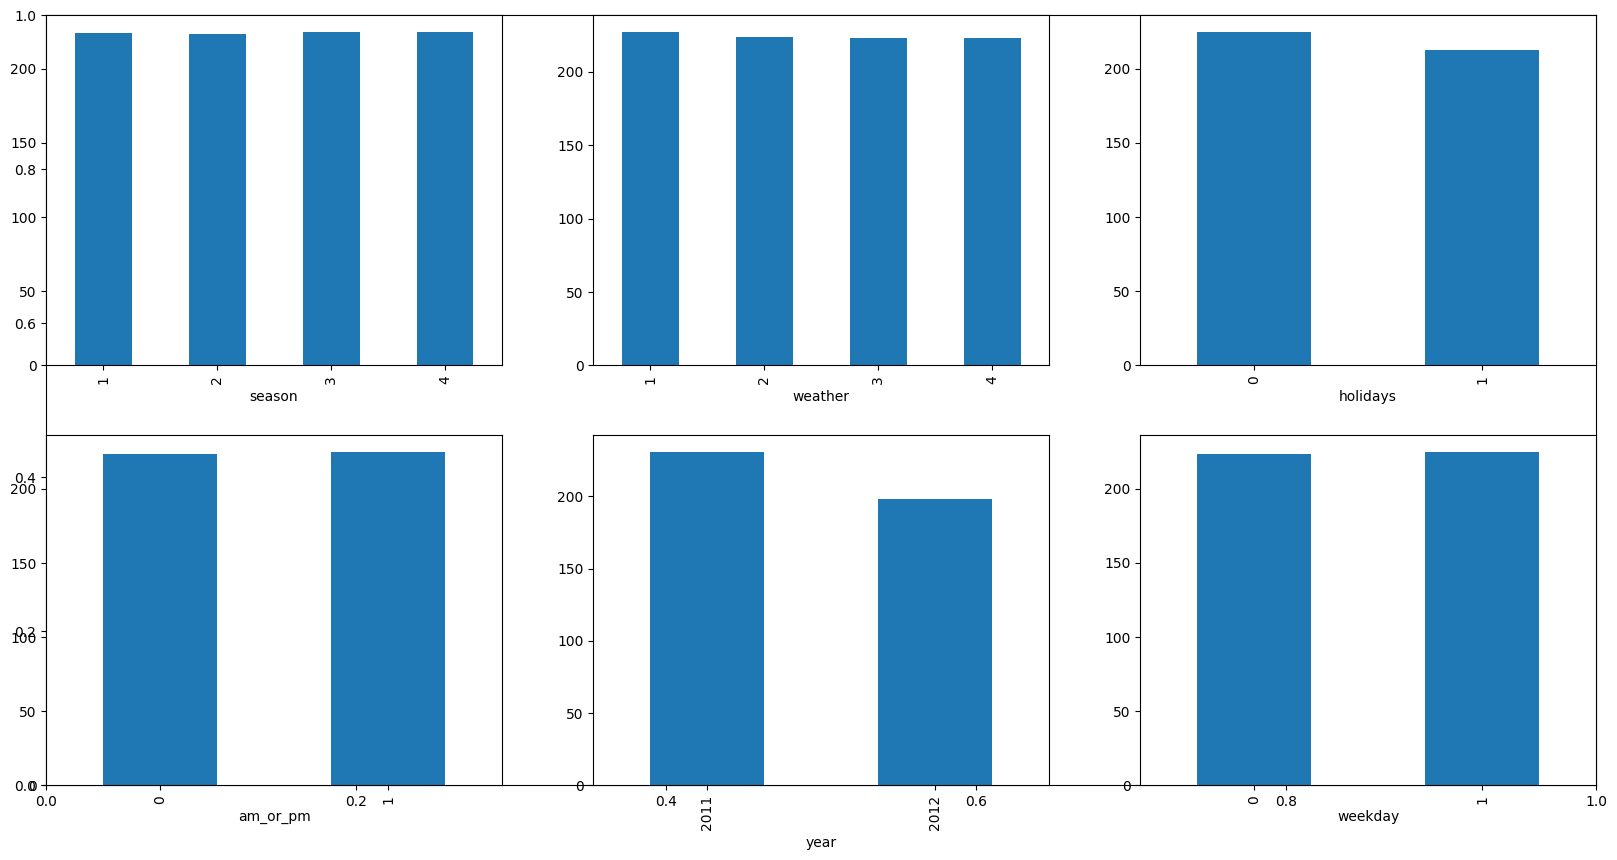

In [15]:
features = ['season', 'weather', 'holidays',\
            'am_or_pm', 'year', 'weekday']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['count'].plot.bar()
plt.show()

### Ride request demand is high in the summer as well as season.

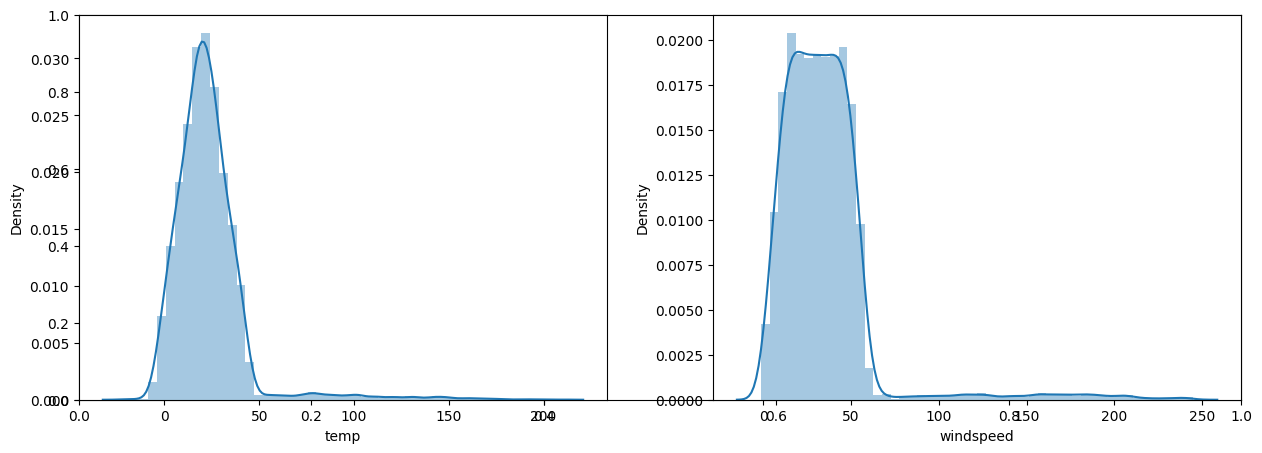

In [16]:
features = ['temp', 'windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sb.distplot(df[col])
plt.show()

### Temperature values are normally distributed but due to the high number of 0 entries in the windspeed column, the data distribution shows some irregularities.

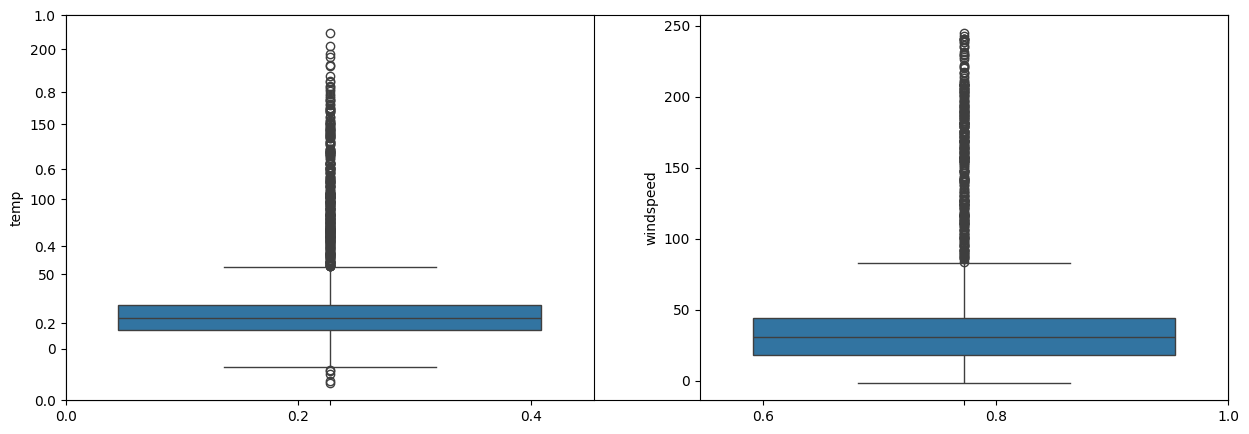

In [17]:
features = ['temp', 'windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sb.boxplot(df[col])
plt.show()

### We have outliers, let's check how much data we will lose if we move outliers.

In [18]:
num_rows = df.shape[0] - df[df['windspeed']<32].shape[0]
print(f'Number of rows that will be lost if we remove outliers is equal to {num_rows}.')

Number of rows that will be lost if we remove outliers is equal to 6091.


### We can remove this many rows because we have around 10000 rows of data so, this much data loss won't affect the learning for our model.

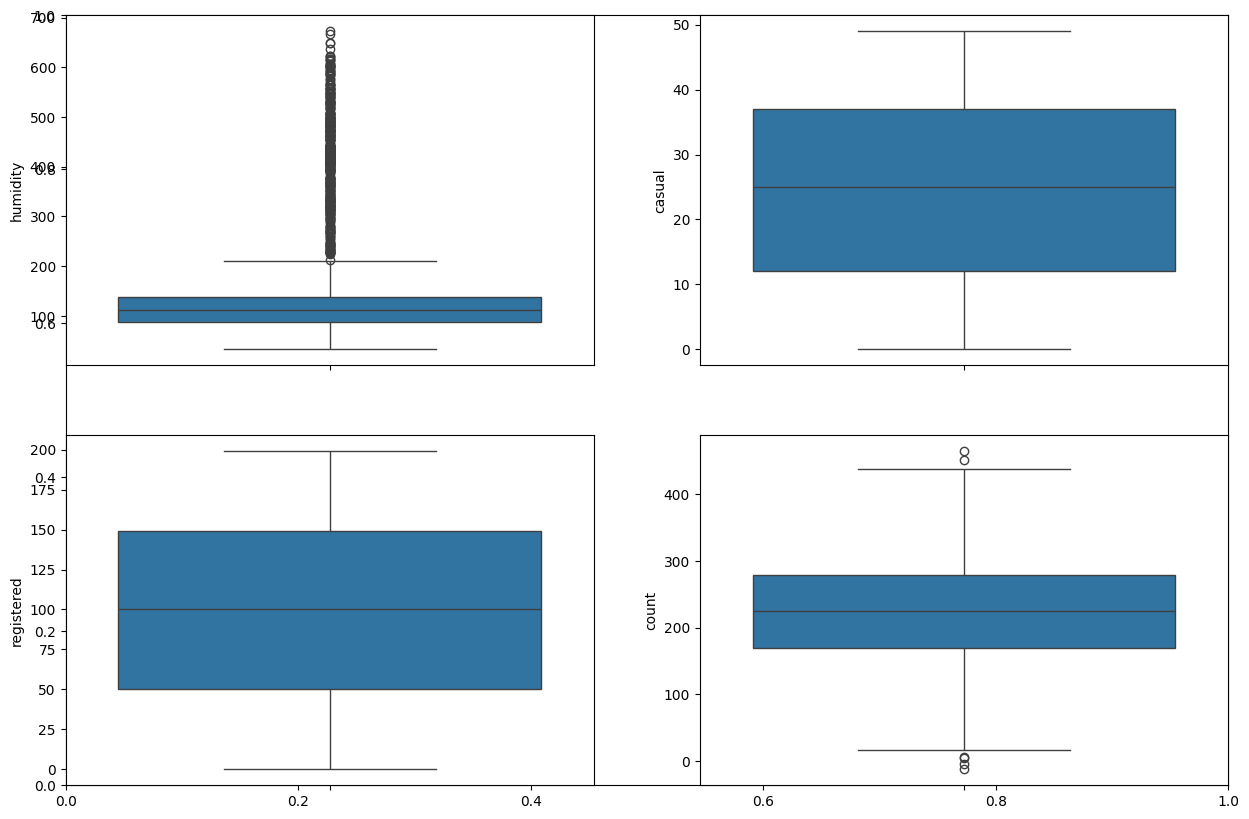

In [19]:
features = ['humidity', 'casual', 'registered', 'count']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sb.boxplot(df[col])
plt.show()

### Now let's check whether there are any highly correlated features in our dataset or not. 

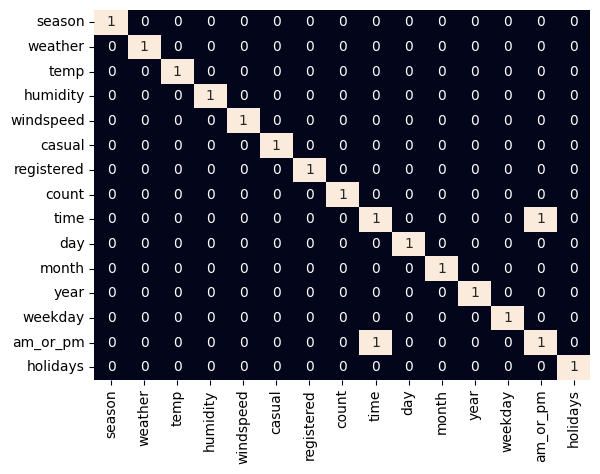

In [20]:
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

### Now, we have to remove the outliers we found in the above two observations that are for the humidity and wind speed.

In [21]:
df.drop(['registered', 'time'], axis=1, inplace=True)
df = df[(df['windspeed'] < 32) & (df['humidity'] > 0)]

## Step 4: Model Training

### Now we will separate the features and target variables and split them into training and the testing data by using which we will select the model which is performing best on the validation data.

In [22]:
features = df.drop(['count'], axis=1)
target = df['count'].values

X_train, X_val, Y_train, Y_val = train_test_split(features,
                                                  target,
                                                  test_size = 0.1,
                                                  random_state=22)
X_train.shape, X_val.shape

((4315, 12), (480, 12))

### Normalizing the data before feeding it into machine learning models helps us to achieve stable and fast training.

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### We have split our data into training and validation data also the normalization of the data has been done. Now let's train some state-of-the-art machine learning models and select the best out of them using the validation dataset.

In [24]:
models = [LinearRegression(), Lasso(), RandomForestRegressor(), Ridge()]

for i in range(len(models)):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} :')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()

LinearRegression() :
Training Error :  55.51892217821355
Validation Error :  55.745841897696785

Lasso() :
Training Error :  55.53694549874652
Validation Error :  55.87072399739354

RandomForestRegressor() :
Training Error :  20.555251442505856
Validation Error :  55.63079175934562

Ridge() :
Training Error :  55.518884098484236
Validation Error :  55.74662268273322



### The predictions made by all the model are fine and we can fine tune model to increase accuracy except RandomForestRegressor. In the case of RandomForestRegressor, there is a little bit of overfitting but we can manage it by hyperparameter tuning.